In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("Downloads/usarrests.csv")

In [3]:
df.head()

,Unnamed: 0,Murder,Assault,UrbanPop
0,Alabama,13.2,236.0,58
1,Alaska,10.0,263.0,48
2,Arizona,8.1,294.0,80
3,Arkansas,8.8,190.0,50
4,California,9.0,276.0,91


In [4]:
df.shape

(50, 4)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  50 non-null     str    
 1   Murder      50 non-null     float64
 2   Assault     49 non-null     float64
 3   UrbanPop    50 non-null     int64  
dtypes: float64(2), int64(1), str(1)
memory usage: 2.1 KB


In [6]:
df.describe

<bound method NDFrame.describe of         Unnamed: 0  Murder  Assault  UrbanPop
0          Alabama    13.2    236.0        58
1           Alaska    10.0    263.0        48
2          Arizona     8.1    294.0        80
3         Arkansas     8.8    190.0        50
4       California     9.0    276.0        91
5         Colorado     7.9    204.0        78
6      Connecticut     3.3    110.0        77
7         Delaware     5.9    238.0        72
8          Florida    15.4    335.0        80
9          Georgia    17.4      NaN        60
10          Hawaii     5.3     46.0        83
11           Idaho     2.6    120.0        54
12        Illinois    10.4    249.0        83
13         Indiana     7.2    113.0        65
14            Iowa     2.2     56.0       570
15          Kansas     6.0    115.0        66
16        Kentucky     9.7    109.0        52
17       Louisiana    15.4    249.0        66
18           Maine     2.1     83.0        51
19        Maryland    11.3    300.0        67


In [7]:
df.describe()

,Murder,Assault,UrbanPop
count,50.00000,49.000000,50.00000
mean,7.78800,182.183673,74.20000
std,4.35551,130.877435,73.40828
min,0.80000,45.000000,6.00000
25%,4.07500,109.000000,53.25000
50%,7.25000,159.000000,66.00000
75%,11.25000,249.000000,77.75000
max,17.40000,879.000000,570.00000


In [8]:
#Urban population maximum precentage is impossible at 570% as a max value posing as an outlier to the data - will need to move the decimal place 1 place over to 57%
#Minimum murder per 100,000 is less than 1 at .8, can not have partial murder - will change value to 1
#879 assult is an outlier that fall way outside the 75% range of 249 - can't say it is impossible but value is up for review

In [9]:
df.isnull().sum()

Unnamed: 0    0
Murder        0
Assault       1
UrbanPop      0
dtype: int64

In [10]:
#There is a missing value for assult in Georgia that will need to be filled in. Will most likely leave blank til more infomration is gathered

In [11]:
import seaborn as sns

<Axes: >

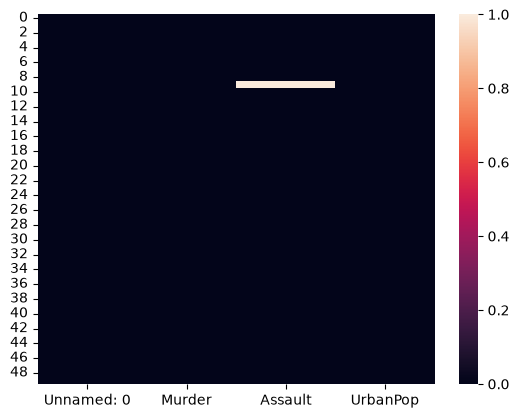

In [12]:
sns.heatmap(df.isnull())

In [13]:
print(df[df['UrbanPop']==570])

   Unnamed: 0  Murder  Assault  UrbanPop
14       Iowa     2.2     56.0       570


In [14]:
#narrow down the outlier of 570 urban pop that would need to be under review but can be changed to 57 for possible decimal error

In [15]:
df.loc[14, 'UrbanPop']=57.0

In [16]:
print(df.loc[14])

Unnamed: 0    Iowa
Murder         2.2
Assault       56.0
UrbanPop        57
Name: 14, dtype: object


In [17]:
df.describe()

,Murder,Assault,UrbanPop
count,50.00000,49.000000,50.000000
mean,7.78800,182.183673,63.940000
std,4.35551,130.877435,16.453286
min,0.80000,45.000000,6.000000
25%,4.07500,109.000000,53.250000
50%,7.25000,159.000000,66.000000
75%,11.25000,249.000000,76.500000
max,17.40000,879.000000,91.000000


In [18]:
#change of urbanpop outlier to 57 for Iowa as there is no 570%

In [19]:
print(df[df['UrbanPop']==6])

   Unnamed: 0  Murder  Assault  UrbanPop
31   New York    11.1    254.0         6


In [20]:
#suspect value of New York being so low considering it being a very populated city and state, would flag for review

In [21]:
high_assault=df[df['Assault']>249]

In [22]:
print(high_assault)

        Unnamed: 0  Murder  Assault  UrbanPop
1           Alaska    10.0    263.0        48
2          Arizona     8.1    294.0        80
4       California     9.0    276.0        91
8          Florida    15.4    335.0        80
19        Maryland    11.3    300.0        67
21        Michigan    12.1    255.0        74
23     Mississippi    16.1    259.0        44
27          Nevada    12.2    252.0        81
30      New Mexico    11.4    285.0        70
31        New York    11.1    254.0         6
32  North Carolina    13.0    337.0        45
39  South Carolina    14.4    879.0        48


In [23]:
#South caronlina would be suspcious as it falls outside of the std range and would need investigation

In [ ]:
#Clean log
#Changed value to Iowa 570 oercent to 57 for possible decimal error
#leaving missing value for Georgia until more data is present
#New York population percentage lower than expected, will need to verify at later time if typo as it is an extemere outlier